#**Air Quality Index Prediction**


In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.dates import DateFormatter
plt.style.use('seaborn-v0_8')
sns.set_palette("Set2")
%matplotlib inline

**Load and Explore the Data**

In [13]:
df = pd.read_csv("merged_openaq.csv")

print("Dataset shape:", df.shape)
print("\nColumns:", df.columns.tolist())
print("\nData types:\n", df.dtypes)
print("\nFirst few rows:")
df.head()

Dataset shape: (119928, 9)

Columns: ['location_id', 'sensors_id', 'location', 'datetime', 'lat', 'lon', 'parameter', 'units', 'value']

Data types:
 location_id      int64
sensors_id       int64
location        object
datetime        object
lat            float64
lon            float64
parameter       object
units           object
value          float64
dtype: object

First few rows:


,location_id,sensors_id,location,datetime,lat,lon,parameter,units,value
0,3409480,12238356,"Bolinj, Virar - MPCB-3379896",2025-02-19T01:45:00+05:30,19.445821,72.798823,pm10,µg/m³,91.15
1,3409480,12238356,"Bolinj, Virar - MPCB-3379896",2025-02-19T02:00:00+05:30,19.445821,72.798823,pm10,µg/m³,90.46
2,3409480,12238356,"Bolinj, Virar - MPCB-3379896",2025-02-19T02:15:00+05:30,19.445821,72.798823,pm10,µg/m³,90.46
3,3409480,12238356,"Bolinj, Virar - MPCB-3379896",2025-02-19T02:30:00+05:30,19.445821,72.798823,pm10,µg/m³,90.46
4,3409480,12238356,"Bolinj, Virar - MPCB-3379896",2025-02-19T02:45:00+05:30,19.445821,72.798823,pm10,µg/m³,93.47


In [14]:
print("Missing values per column:")
print(df.isna().sum())

unique_parameters = df['parameter'].unique()
print("\nUnique parameters:", unique_parameters)

Missing values per column:
location_id    0
sensors_id     0
location       0
datetime       0
lat            0
lon            0
parameter      0
units          0
value          0
dtype: int64

Unique parameters: ['pm10' 'pm25' 'o3' 'no2' 'no' 'relativehumidity' 'temperature' 'so2' 'co']


**Data Preprocessing and Cleaning**

In [15]:
datetime_col = None
for c in df.columns:
    if "date" in c.lower() or "time" in c.lower():
        datetime_col = c
        break

print("Datetime column:", datetime_col)

Datetime column: datetime


*Convert to datetime & set as index*

In [16]:
df[datetime_col] = pd.to_datetime(df[datetime_col], errors="coerce")
df = df.dropna(subset=[datetime_col])
df = df.set_index(datetime_col).sort_index()

In [17]:
if "parameter" in df.columns and "value" in df.columns:
    df = df.pivot_table(values="value", index=df.index, columns="parameter", aggfunc="mean")

In [18]:
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_")

print("Processed data shape:", df.shape)
df.head()

Processed data shape: (13372, 9)


parameter,co,no,no2,o3,pm10,pm25,relativehumidity,so2,temperature
datetime,,,,,,,,,
2025-02-19 01:45:00+05:30,0.43,0.08,21.06,29.94,91.15,42.62,75.6,19.91,26.37
2025-02-19 02:00:00+05:30,0.43,0.09,22.99,26.40,90.46,42.35,75.6,20.52,26.36
2025-02-19 02:15:00+05:30,0.44,0.11,25.45,23.92,90.46,42.35,75.6,22.37,26.22
2025-02-19 02:30:00+05:30,0.44,0.10,25.08,22.44,90.46,42.35,75.6,21.70,26.15
2025-02-19 02:45:00+05:30,0.43,0.12,25.19,21.56,93.47,43.66,75.6,23.56,26.14


In [19]:
print("Missing values before handling:")
print(df.isna().sum())

df = df.ffill().bfill()

print("\nMissing values after handling:")
print(df.isna().sum())

df.describe()

Missing values before handling:
parameter
co                  74
no                  55
no2                 60
o3                  73
pm10                 3
pm25                15
relativehumidity    43
so2                 65
temperature         32
dtype: int64

Missing values after handling:
parameter
co                  0
no                  0
no2                 0
o3                  0
pm10                0
pm25                0
relativehumidity    0
so2                 0
temperature         0
dtype: int64


parameter,co,no,no2,o3,pm10,pm25,relativehumidity,so2,temperature
count,13372.000000,13372.000000,13372.000000,13372.000000,13372.000000,13372.000000,13372.000000,13372.000000,13372.000000
mean,0.693098,10.639749,20.332967,32.315502,60.938995,26.444103,50.338916,5.380675,29.615675
std,0.645175,17.695253,16.092887,34.457249,34.671662,24.166976,9.460294,9.291181,1.984881
min,0.000000,0.000000,0.000000,0.000000,0.000000,-7.240000,46.300000,-3.400000,4.000000
25%,0.320000,1.290000,10.250000,12.620000,38.510000,14.290000,46.300000,1.850000,28.120000
50%,0.510000,5.220000,15.990000,22.230000,55.000000,20.810000,46.300000,2.780000,29.980000
75%,0.850000,14.270000,25.172500,42.112500,76.252500,32.030000,46.300000,6.062500,31.140000
max,8.060000,290.180000,155.320000,891.380000,343.830000,476.000000,75.600000,203.810000,33.500000


**Exploratory Data Analysis (EDA Pipeline)**

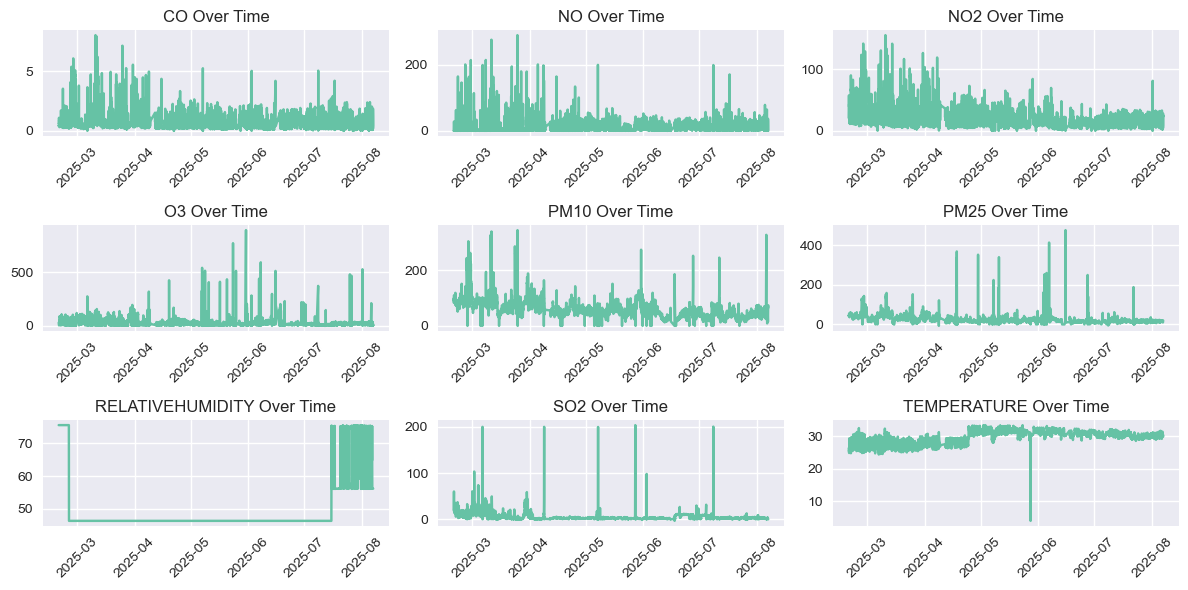

In [20]:
plt.figure(figsize=(12, 6))

for i, col in enumerate(df.columns, 1):
    plt.subplot(3, 3, i)
    plt.plot(df.index, df[col])
    plt.title(f"{col.upper()} Over Time")
    plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

Breakpoints for AQI levels

In [21]:
breakpoints = {
    "pm25": [(0,30,0,50),(31,60,51,100),(61,90,101,200),(91,120,201,300),(121,250,301,400),(251,500,401,500)],
    "pm10": [(0,50,0,50),(51,100,51,100),(101,250,101,200),(251,350,201,300),(351,430,301,400),(431,500,401,500)],
    "no2": [(0,40,0,50),(41,80,51,100),(81,180,101,200),(181,280,201,300),(281,400,301,400),(401,1000,401,500)],
    "so2": [(0,40,0,50),(41,80,51,100),(81,380,101,200),(381,800,201,300),(801,1600,301,400),(1601,2000,401,500)],
    "co":  [(0,1,0,50),(1.1,2,51,100),(2.1,10,101,200),(10.1,17,201,300),(17.1,34,301,400),(34.1,50,401,500)],
    "o3":  [(0,50,0,50),(51,100,51,100),(101,168,101,200),(169,208,201,300),(209,748,301,400),(749,1000,401,500)],
}

In [22]:
def compute_subindex(pollutant, value):
    if pollutant not in breakpoints or np.isnan(value):
        return None
    for (bp_lo, bp_hi, i_lo, i_hi) in breakpoints[pollutant]:
        if bp_lo <= value <= bp_hi:
            return ((i_hi-i_lo)/(bp_hi-bp_lo))*(value-bp_lo)+i_lo
    return None

In [23]:
def calculate_aqi(row):
    sub_indices = []
    for pollutant in breakpoints.keys():
        if pollutant in row:
            si = compute_subindex(pollutant, row[pollutant])
            if si is not None:
                sub_indices.append(si)
    return max(sub_indices) if sub_indices else None

Calculate AQI for each Row

In [24]:
df["AQI"] = df.apply(calculate_aqi, axis=1)

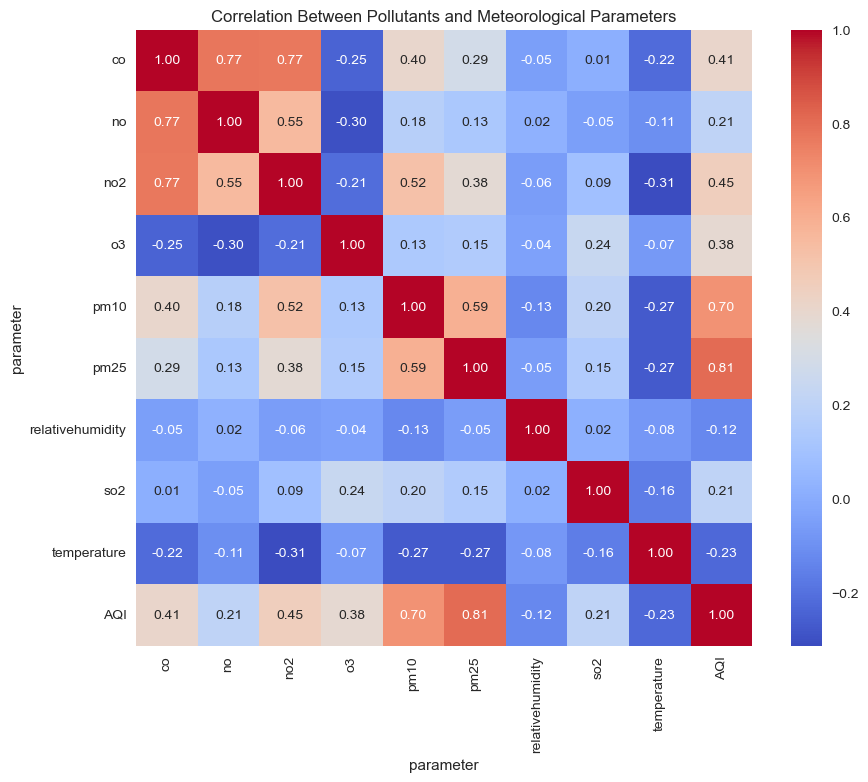

In [25]:
plt.figure(figsize=(10, 8))
corr_matrix = df.corr()
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f", square=True)
plt.title("Correlation Between Pollutants and Meteorological Parameters")
plt.show()

In [26]:
df_daily = df.resample("D").mean()
df_daily['AQI'] = df_daily['AQI'].interpolate()

print("Daily AQI data shape:", df_daily.shape)
df_daily.head()

Daily AQI data shape: (169, 10)


parameter,co,no,no2,o3,pm10,pm25,relativehumidity,so2,temperature,AQI
datetime,,,,,,,,,,
2025-02-19 00:00:00+05:30,0.503933,1.299888,23.020449,50.444157,92.695281,49.823820,75.6,24.125393,26.960562,93.445176
2025-02-20 00:00:00+05:30,0.498333,2.656111,21.998889,60.265778,82.285111,50.160222,75.6,15.853222,27.286222,86.999895
2025-02-21 00:00:00+05:30,0.421000,2.900889,19.789333,51.270889,73.322111,33.892000,75.6,17.277556,28.192000,74.341451
2025-02-22 00:00:00+05:30,0.469130,3.577283,24.700761,52.762283,92.451848,43.521413,75.6,9.332174,27.891957,92.073630
2025-02-23 00:00:00+05:30,0.537609,9.619022,24.215870,51.516413,97.328804,44.763043,75.6,10.502283,28.007609,95.786962


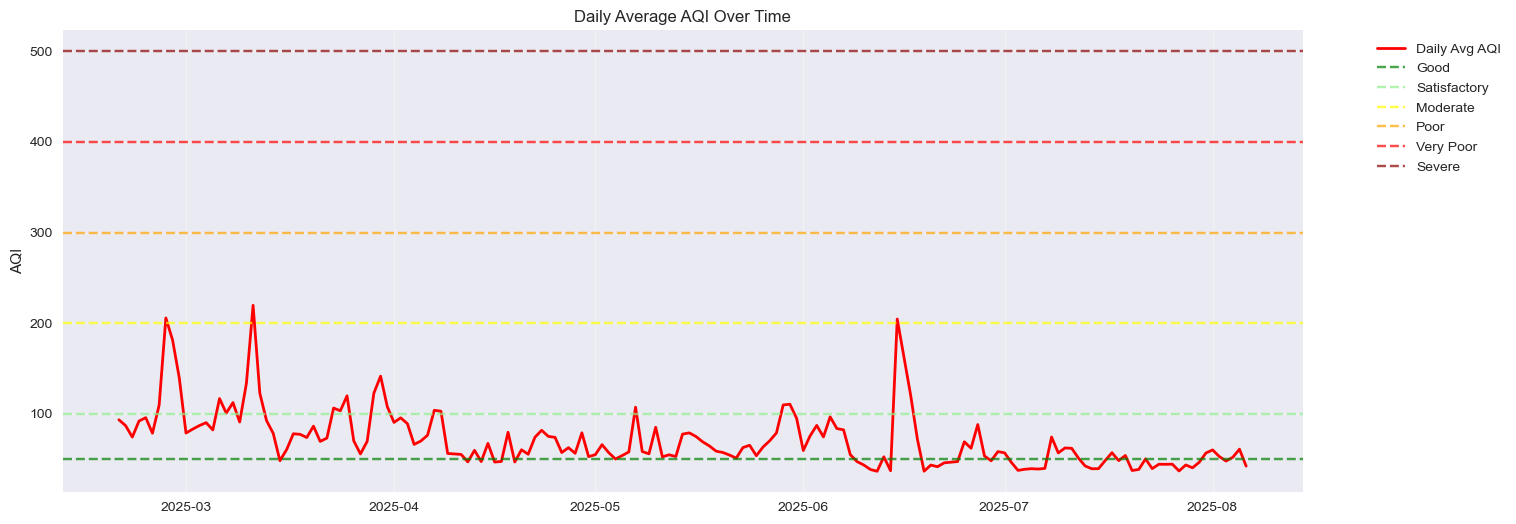

In [27]:
plt.figure(figsize=(16, 6))
plt.plot(df_daily.index, df_daily["AQI"], label="Daily Avg AQI", color="red", linewidth=2)

plt.axhline(50, color="green", linestyle="--", alpha=0.7, label="Good")
plt.axhline(100, color="lightgreen", linestyle="--", alpha=0.7, label="Satisfactory")
plt.axhline(200, color="yellow", linestyle="--", alpha=0.7, label="Moderate")
plt.axhline(300, color="orange", linestyle="--", alpha=0.7, label="Poor")
plt.axhline(400, color="red", linestyle="--", alpha=0.7, label="Very Poor")
plt.axhline(500, color="darkred", linestyle="--", alpha=0.7, label="Severe")

plt.title("Daily Average AQI Over Time")
plt.ylabel("AQI")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, alpha=0.3)
plt.show()

In [28]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

df_daily["AQI_Category"] = df_daily["AQI"].apply(categorize_aqi)


C:\Users\archa\AppData\Local\Temp\ipykernel_7940\993867530.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=df_daily["AQI_Category"], order=category_order, palette="viridis")


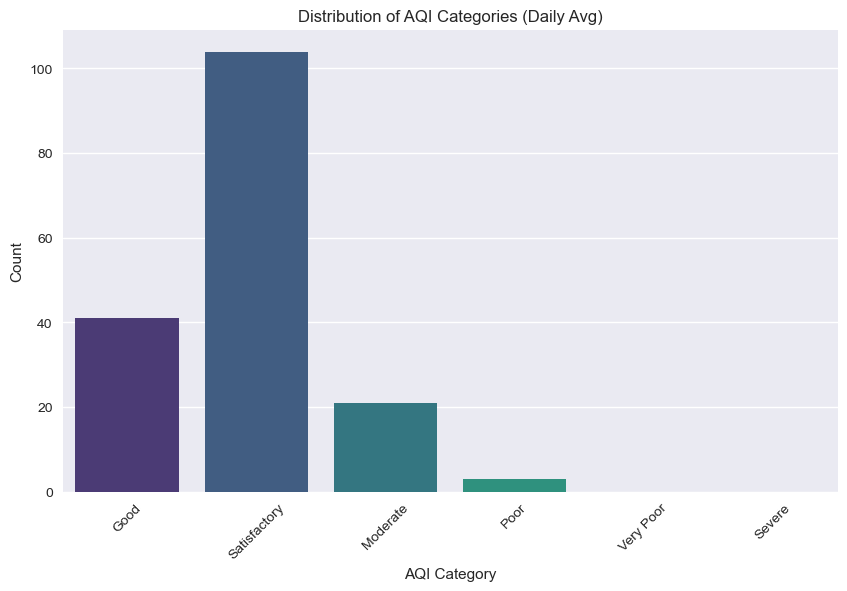

In [29]:
plt.figure(figsize=(10, 6))
category_order = ["Good", "Satisfactory", "Moderate", "Poor", "Very Poor", "Severe"]
sns.countplot(x=df_daily["AQI_Category"], order=category_order, palette="viridis")
plt.title("Distribution of AQI Categories (Daily Avg)")
plt.xlabel("AQI Category")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


In [40]:
def create_features(df, target_col="AQI", lags=[1, 2, 7], windows=[3, 7]):
    df = df.copy()

    #lag features
    for lag in lags:
        df[f"lag_{lag}"] = df[target_col].shift(lag)

    #rolling features
    for window in windows:
        df[f"rolling_mean_{window}"] = df[target_col].shift(1).rolling(window=window).mean()
        df[f"rolling_std_{window}"] = df[target_col].shift(1).rolling(window=window).std()

    #Time-based features
    df["day"] = df.index.day
    df["month"] = df.index.month
    df["day_of_week"] = df.index.dayofweek
    df["week_of_year"] = df.index.isocalendar().week

    return df.dropna()

Apply Lag-rolling & time based features

In [41]:
df_feats = create_features(df_daily)

Split into Train-Val-Test

In [42]:
train_end = "2025-07-15"
val_end = "2025-07-31"

In [48]:
train = df_feats.loc[:train_end]
val = df_feats.loc[train_end:val_end]
test = df_feats.loc[val_end:]

In [49]:
print("Data split sizes:")
print("Train:", len(train))
print("Validation:", len(val))
print("Test:", len(test))

Data split sizes:
Train: 138
Validation: 17
Test: 7


Features & Target

In [50]:
X_train = train.drop(columns=["AQI", "AQI_Category"], errors="ignore")
X_val = val.drop(columns=["AQI", "AQI_Category"], errors="ignore")
X_test = test.drop(columns=["AQI", "AQI_Category"], errors="ignore")

y_train = train["AQI"]
y_val = val["AQI"]
y_test = test["AQI"]

print("Feature matrix shapes:")
print("X_train:", X_train.shape)
print("X_val:", X_val.shape)
print("X_test:", X_test.shape)

Feature matrix shapes:
X_train: (138, 20)
X_val: (17, 20)
X_test: (7, 20)


Parameter grid for Random Forest

In [51]:
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.model_selection import GridSearchCV, TimeSeriesSplit
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

In [52]:
param_grid = {
    "n_estimators": [100, 200, 300],
    "max_depth": [5, 10, 15, None],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

In [53]:
tscv = TimeSeriesSplit(n_splits=3)

In [54]:
grid_search = GridSearchCV(
    estimator=RandomForestRegressor(random_state=42, n_jobs=-1),
    param_grid=param_grid,
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)
grid_search.fit(X_train, y_train)

print("Best Parameters:", grid_search.best_params_)
print("Best CV RMSE:", (-grid_search.best_score_)**0.5)

Fitting 3 folds for each of 324 candidates, totalling 972 fits
Best Parameters: {'max_depth': 10, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 5, 'n_estimators': 300}
Best CV RMSE: 14.959410331509753


In [55]:
best_rf = RandomForestRegressor(
    **grid_search.best_params_,
    random_state=42,
    n_jobs=-1
)

X_trainval = pd.concat([X_train, X_val])
y_trainval = pd.concat([y_train, y_val])

best_rf.fit(X_trainval, y_trainval)

RandomForestRegressor(max_depth=10, max_features=None, min_samples_leaf=2,
                      min_samples_split=5, n_estimators=300, n_jobs=-1,
                      random_state=42)

In [56]:
train_pred = best_rf.predict(X_train)
val_pred = best_rf.predict(X_val)
test_pred = best_rf.predict(X_test)

In [59]:
def evaluate_model(y_true, y_pred, set_name):
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    mae = mean_absolute_error(y_true, y_pred)
    r2 = r2_score(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    print(f"{set_name} Metrics:")
    print(f"RMSE: {rmse:.2f}")
    print(f"MAE: {mae:.2f}")
    print(f"R²: {r2:.4f}")
    print(f"MAPE: {mape:.2f}%")
    print("-" * 40)

    return rmse, mae, r2, mape

print("Model Evaluation Results:")
print("=" * 40)
train_metrics = evaluate_model(y_train, train_pred, "Training")
val_metrics = evaluate_model(y_val, val_pred, "Validation")
test_metrics = evaluate_model(y_test, test_pred, "Test")

Model Evaluation Results:
Training Metrics:
RMSE: 6.15
MAE: 3.39
R²: 0.9638
MAPE: 3.99%
----------------------------------------
Validation Metrics:
RMSE: 1.88
MAE: 1.57
R²: 0.9099
MAPE: 3.58%
----------------------------------------
Test Metrics:
RMSE: 2.65
MAE: 2.12
R²: 0.8175
MAPE: 4.11%
----------------------------------------


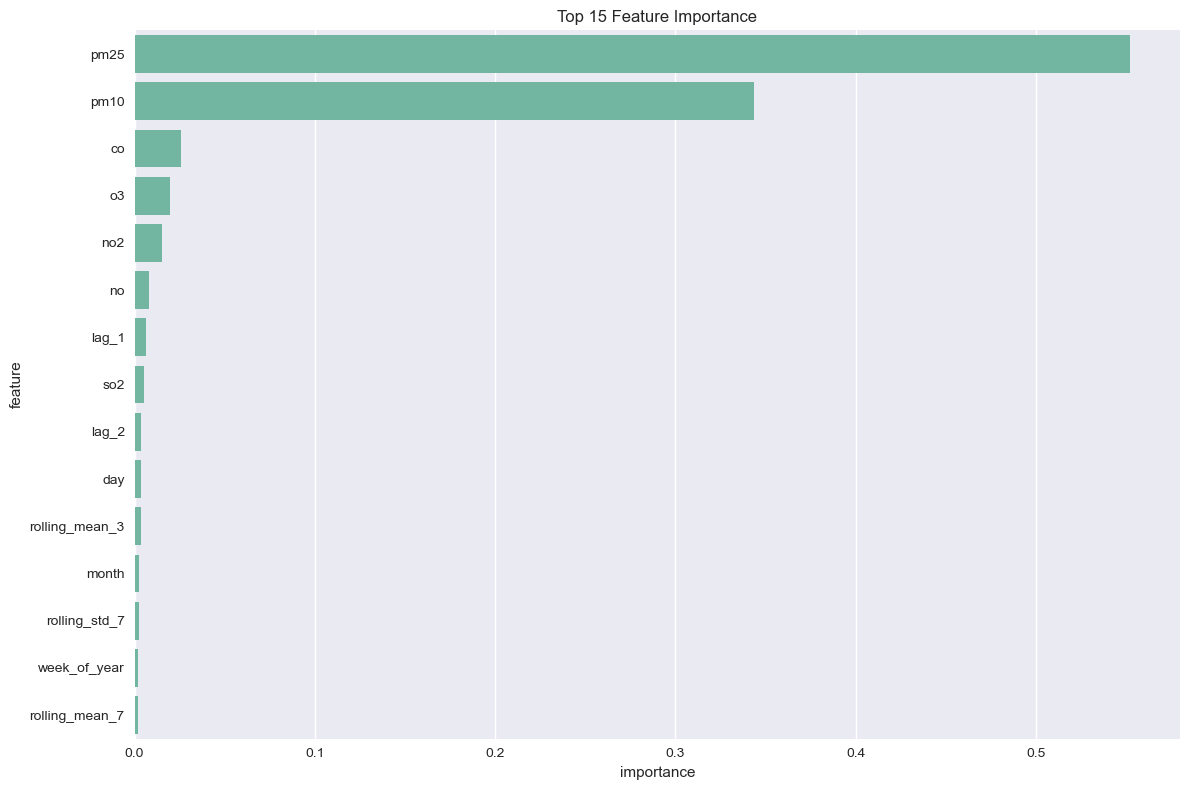

In [60]:
feature_importance = pd.DataFrame({
    'feature': X_train.columns,
    'importance': best_rf.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(12, 8))
sns.barplot(x='importance', y='feature', data=feature_importance.head(15))
plt.title('Top 15 Feature Importance')
plt.tight_layout()
plt.show()

Prediction Vs Actual

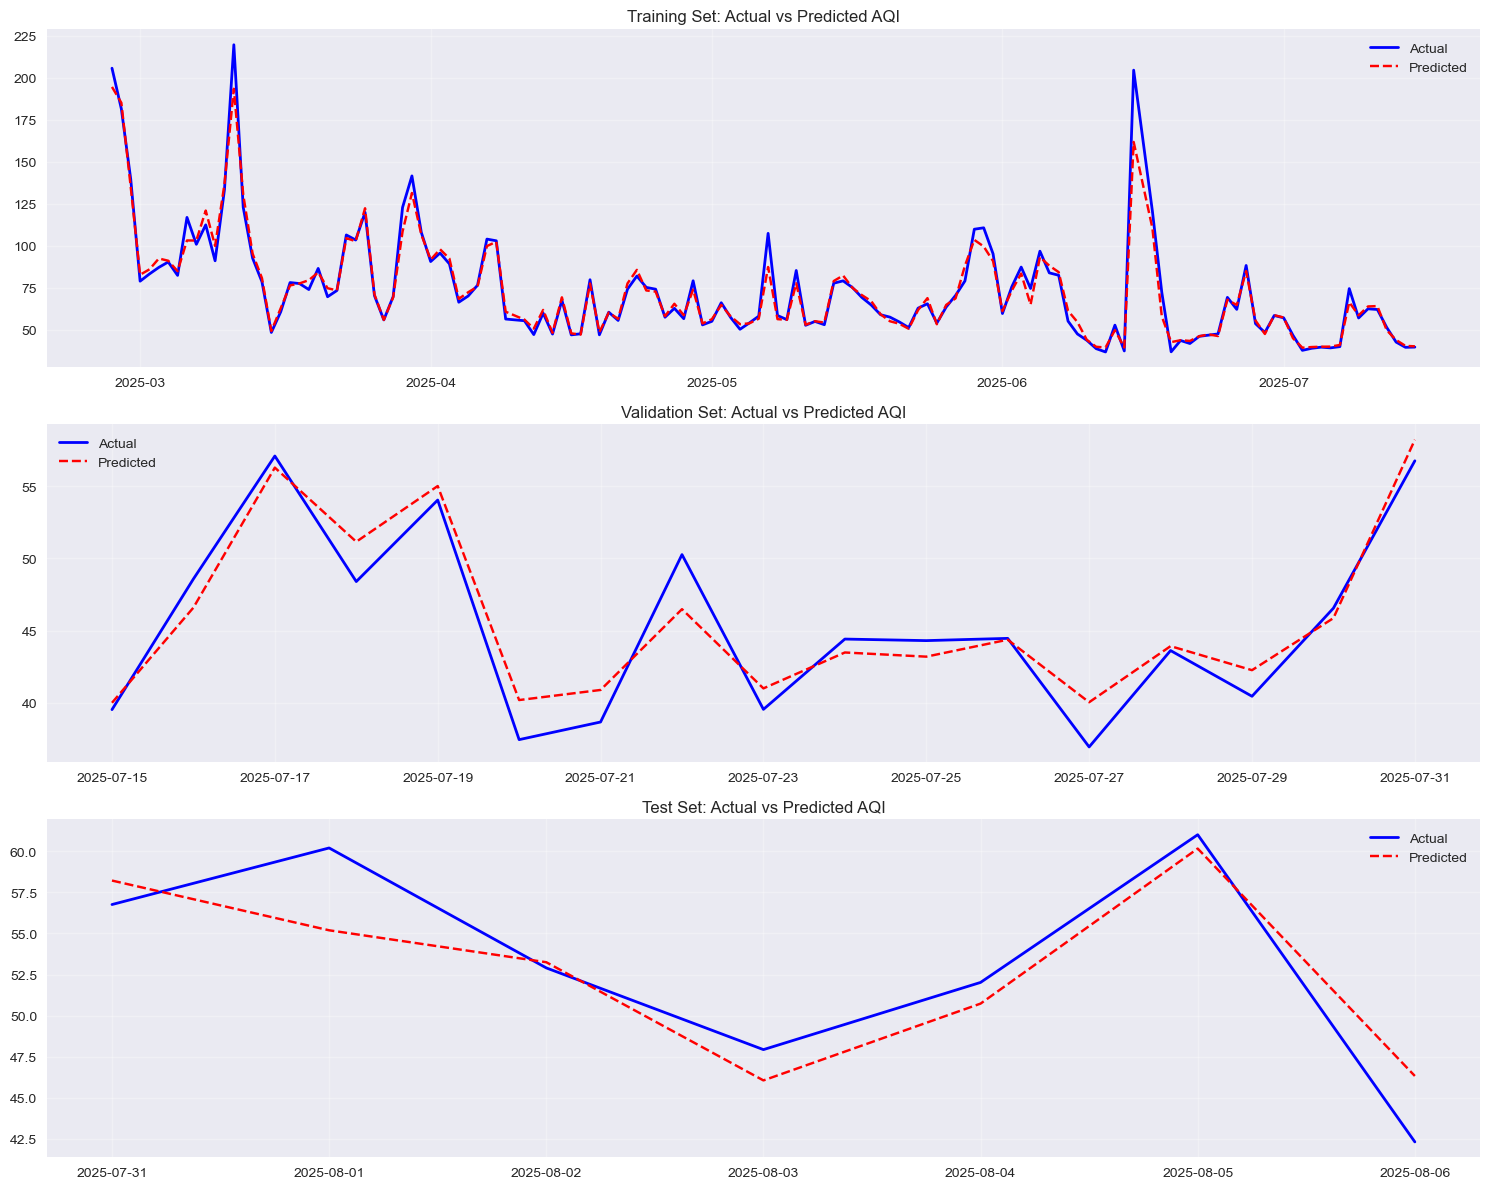

In [61]:
fig, axes = plt.subplots(3, 1, figsize=(15, 12))

# Training set
axes[0].plot(y_train.index, y_train, label="Actual", color="blue", linewidth=2)
axes[0].plot(y_train.index, train_pred, label="Predicted", color="red", linestyle="--")
axes[0].set_title("Training Set: Actual vs Predicted AQI")
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# Validation set
axes[1].plot(y_val.index, y_val, label="Actual", color="blue", linewidth=2)
axes[1].plot(y_val.index, val_pred, label="Predicted", color="red", linestyle="--")
axes[1].set_title("Validation Set: Actual vs Predicted AQI")
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# Test set
axes[2].plot(y_test.index, y_test, label="Actual", color="blue", linewidth=2)
axes[2].plot(y_test.index, test_pred, label="Predicted", color="red", linestyle="--")
axes[2].set_title("Test Set: Actual vs Predicted AQI")
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

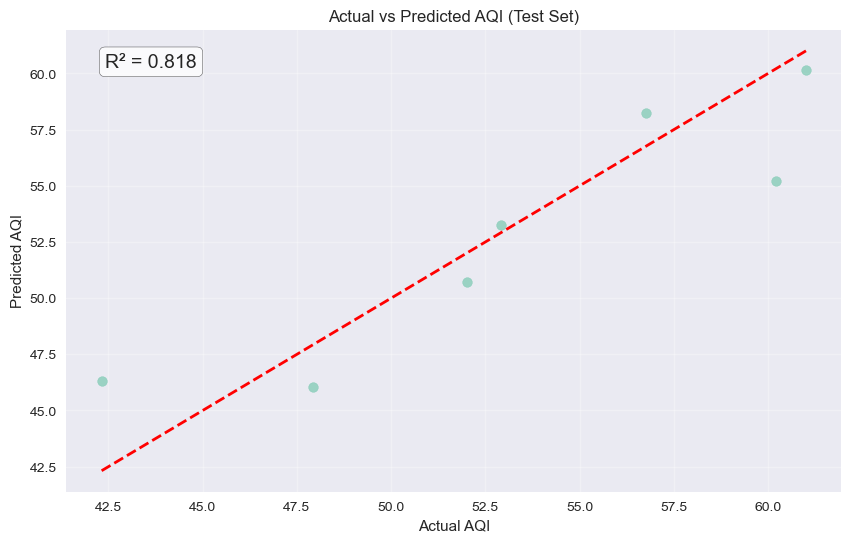

In [62]:
#pred vs actual
plt.figure(figsize=(10, 6))
plt.scatter(y_test, test_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Test Set)")
plt.grid(True, alpha=0.3)

#R2 value
r2 = r2_score(y_test, test_pred)
plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

#Hourly Model using Gradient Boosting

In [63]:
def create_hourly_features(df, target_col="AQI"):
    df = df.copy()

    #Time based
    df["hour"] = df.index.hour
    df["day_of_week"] = df.index.dayofweek
    df["day_of_month"] = df.index.day
    df["month"] = df.index.month
    df["week_of_year"] = df.index.isocalendar().week

    # Lag features (previous hours)
    for lag in [1, 2, 3, 6, 12, 24]:
        df[f"lag_{lag}h"] = df[target_col].shift(lag)

    # Rolling statistics
    for window in [3, 6, 12, 24]:
        df[f"rolling_mean_{window}h"] = df[target_col].shift(1).rolling(window=window).mean()
        df[f"rolling_std_{window}h"] = df[target_col].shift(1).rolling(window=window).std()

    return df.dropna()

In [64]:
# Calc AQI for hourly
df_hourly = df.copy()
df_hourly["AQI"] = df_hourly.apply(calculate_aqi, axis=1)

In [65]:
#feature engg
df_hourly_feats = create_hourly_features(df_hourly)

In [66]:
#Split
train_hourly = df_hourly_feats.loc[:train_end]
val_hourly = df_hourly_feats.loc[train_end:val_end]
test_hourly = df_hourly_feats.loc[val_end:]

In [67]:
#feat & target
X_train_h = train_hourly.drop(columns=["AQI"], errors="ignore")
X_val_h = val_hourly.drop(columns=["AQI"], errors="ignore")
X_test_h = test_hourly.drop(columns=["AQI"], errors="ignore")

y_train_h = train_hourly["AQI"]
y_val_h = val_hourly["AQI"]
y_test_h = test_hourly["AQI"]
X_train_h.shape, X_val_h.shape, X_test_h.shape
y_train_h.shape, y_val_h.shape, y_test_h.shape

((11538,), (1471,), (513,))

In [68]:
#Params
param_grid_gbr = {
    "n_estimators": [100, 200, 300],
    "learning_rate": [0.01, 0.1, 0.2],
    "max_depth": [3, 5, 7],
    "min_samples_split": [2, 5, 10],
    "min_samples_leaf": [1, 2, 4],
    "max_features": ["sqrt", "log2", None]
}

tscv = TimeSeriesSplit(n_splits=3)

grid_search_gbr = GridSearchCV(
    estimator=GradientBoostingRegressor(random_state=42),
    param_grid=param_grid_gbr,
    scoring="neg_mean_squared_error",
    cv=tscv,
    n_jobs=-1,
    verbose=1
)
grid_search_gbr.fit(X_train_h, y_train_h)

print("Best Parameters (Gradient Boosting):", grid_search_gbr.best_params_)
print("Best CV RMSE (Gradient Boosting):", (-grid_search_gbr.best_score_)**0.5)

hourly_model = GradientBoostingRegressor(
    **grid_search_gbr.best_params_,
    random_state=42
)
hourly_model.fit(X_train_h, y_train_h)

Fitting 3 folds for each of 729 candidates, totalling 2187 fits
Best Parameters (Gradient Boosting): {'learning_rate': 0.1, 'max_depth': 7, 'max_features': None, 'min_samples_leaf': 2, 'min_samples_split': 2, 'n_estimators': 300}
Best CV RMSE (Gradient Boosting): 10.489339885507437


GradientBoostingRegressor(max_depth=7, min_samples_leaf=2, n_estimators=300,
                          random_state=42)

In [70]:
#PRED
train_pred_h = hourly_model.predict(X_train_h)
val_pred_h = hourly_model.predict(X_val_h)
test_pred_h = hourly_model.predict(X_test_h)

In [71]:
#Evaluate
print("Hourly Model Evaluation:")
print("=" * 40)
train_metrics_h = evaluate_model(y_train_h, train_pred_h, "Training (Hourly)")
val_metrics_h = evaluate_model(y_val_h, val_pred_h, "Validation (Hourly)")
test_metrics_h = evaluate_model(y_test_h, test_pred_h, "Test (Hourly)")

Hourly Model Evaluation:
Training (Hourly) Metrics:
RMSE: 0.49
MAE: 0.35
R²: 0.9999
MAPE: 0.61%
----------------------------------------
Validation (Hourly) Metrics:
RMSE: 1.72
MAE: 1.08
R²: 0.9950
MAPE: 2.76%
----------------------------------------
Test (Hourly) Metrics:
RMSE: 4.80
MAE: 1.42
R²: 0.9717
MAPE: 2.58%
----------------------------------------


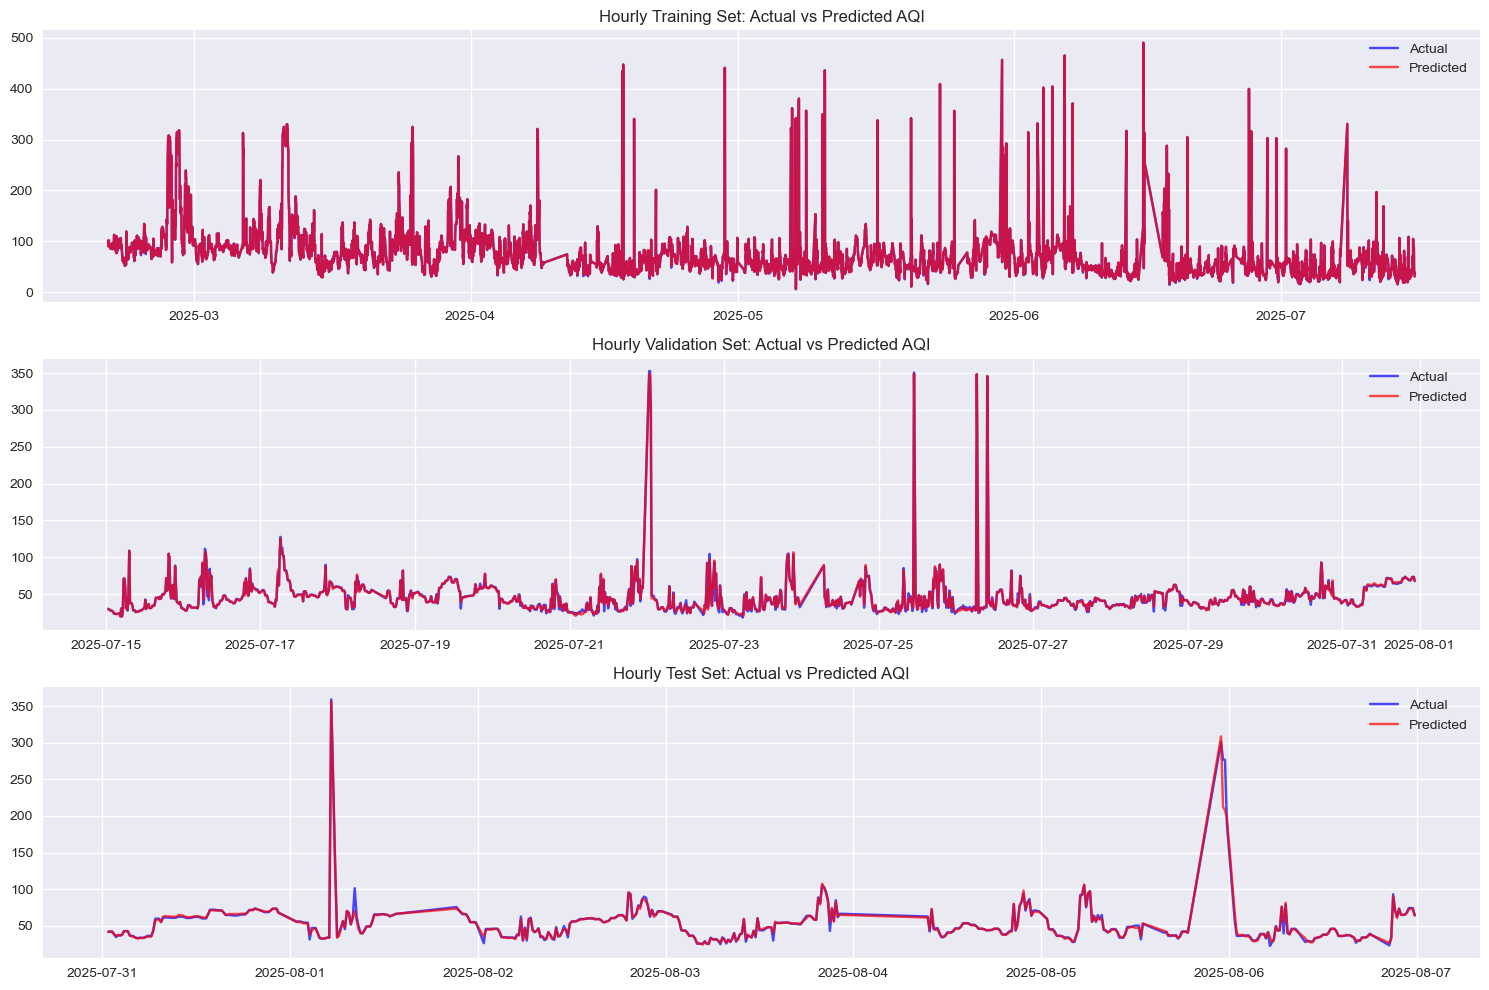

In [72]:
plt.figure(figsize=(15, 10))

#Train
plt.subplot(3, 1, 1)
plt.plot(y_train_h.index, y_train_h, label="Actual", color="blue", alpha=0.7)
plt.plot(y_train_h.index, train_pred_h, label="Predicted", color="red", alpha=0.7)
plt.title("Hourly Training Set: Actual vs Predicted AQI")
plt.legend()

#Val
plt.subplot(3, 1, 2)
plt.plot(y_val_h.index, y_val_h, label="Actual", color="blue", alpha=0.7)
plt.plot(y_val_h.index, val_pred_h, label="Predicted", color="red", alpha=0.7)
plt.title("Hourly Validation Set: Actual vs Predicted AQI")
plt.legend()

#Test
plt.subplot(3, 1, 3)
plt.plot(y_test_h.index, y_test_h, label="Actual", color="blue", alpha=0.7)
plt.plot(y_test_h.index, test_pred_h, label="Predicted", color="red", alpha=0.7)
plt.title("Hourly Test Set: Actual vs Predicted AQI")
plt.legend()

plt.tight_layout()
plt.show()

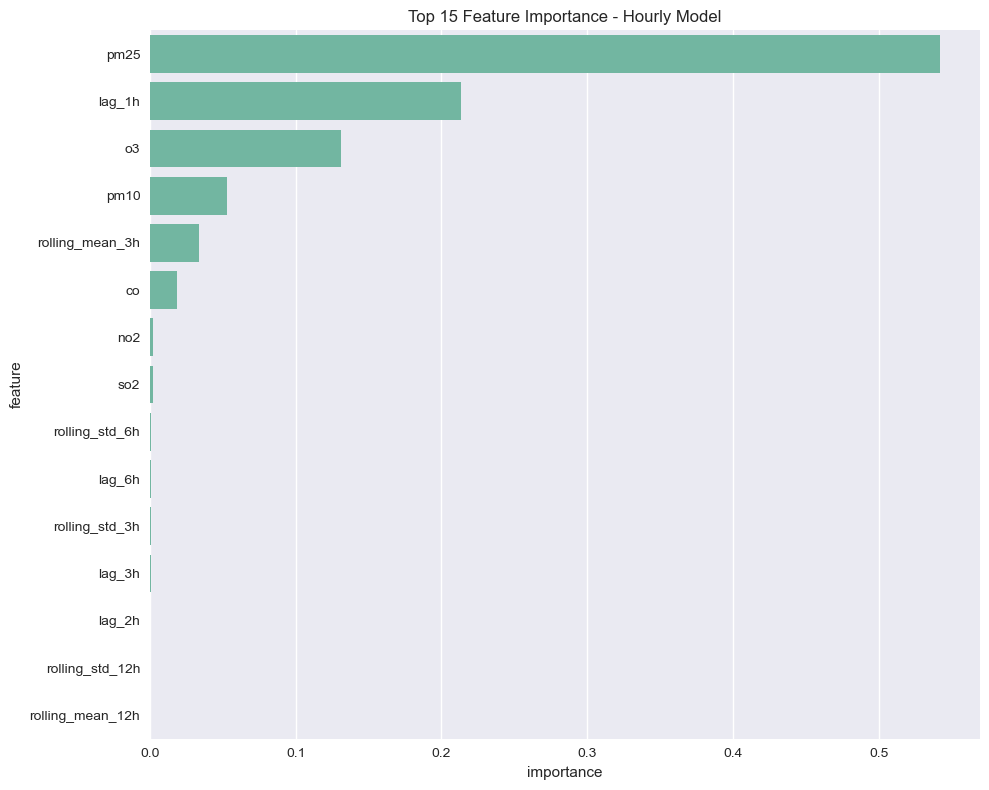

In [73]:
# Feature importance for hourly model
feature_importance_h = pd.DataFrame({
    'feature': X_train_h.columns,
    'importance': hourly_model.feature_importances_
}).sort_values('importance', ascending=False)

plt.figure(figsize=(10, 8))
sns.barplot(x='importance', y='feature', data=feature_importance_h.head(15))
plt.title('Top 15 Feature Importance - Hourly Model')
plt.tight_layout()
plt.show()

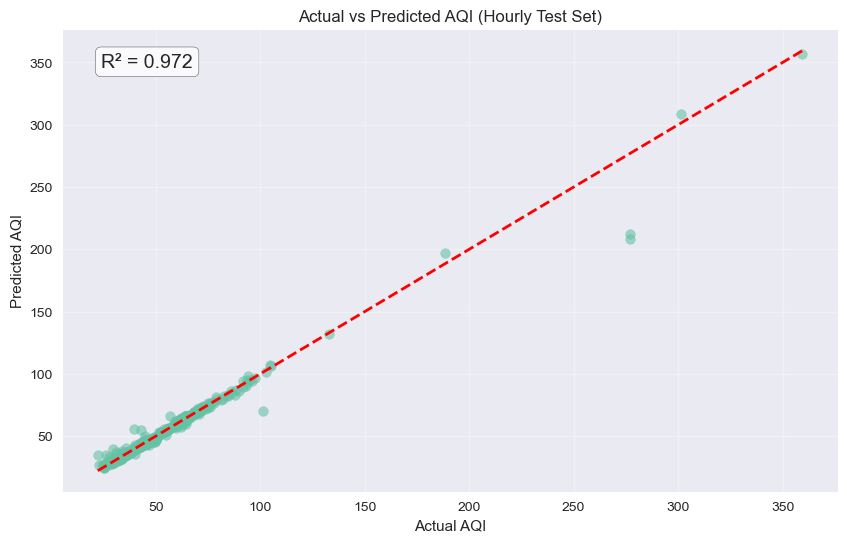

In [74]:
plt.figure(figsize=(10, 6))
plt.scatter(y_test_h, test_pred_h, alpha=0.6)
plt.plot([y_test_h.min(), y_test_h.max()], [y_test_h.min(), y_test_h.max()], 'r--', lw=2)
plt.xlabel("Actual AQI")
plt.ylabel("Predicted AQI")
plt.title("Actual vs Predicted AQI (Hourly Test Set)")
plt.grid(True, alpha=0.3)

#R2
r2 = r2_score(y_test_h, test_pred_h)
plt.text(0.05, 0.95, f'R² = {r2:.3f}', transform=plt.gca().transAxes,
         fontsize=14, verticalalignment='top', bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))

plt.show()

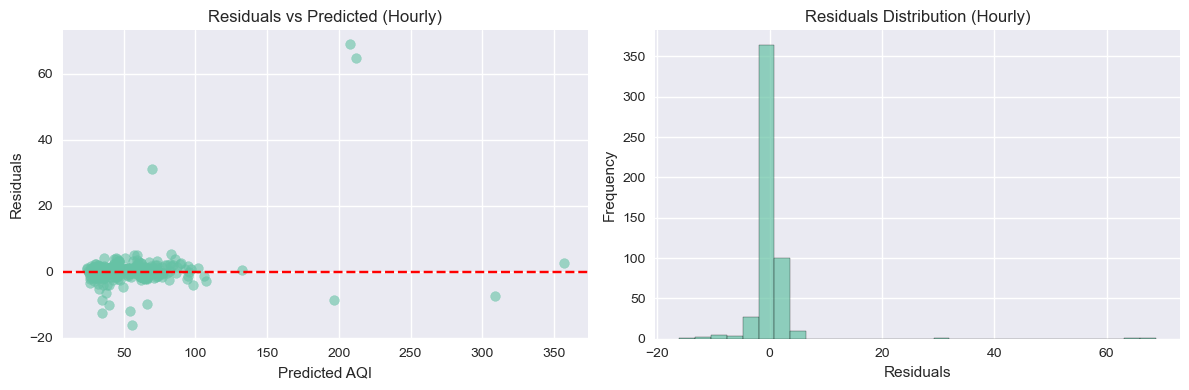

In [75]:
residuals = y_test_h - test_pred_h

plt.figure(figsize=(12, 4))

#Res vs Pred
plt.subplot(1, 2, 1)
plt.scatter(test_pred_h, residuals, alpha=0.6)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted AQI')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted (Hourly)')

# Residuals distribution
plt.subplot(1, 2, 2)
plt.hist(residuals, bins=30, alpha=0.7, edgecolor='black')
plt.xlabel('Residuals')
plt.ylabel('Frequency')
plt.title('Residuals Distribution (Hourly)')

plt.tight_layout()
plt.show()

Daily Aggregation of Hourly Predictions:
RMSE: 0.92
MAE: 0.66
R²: 0.9779


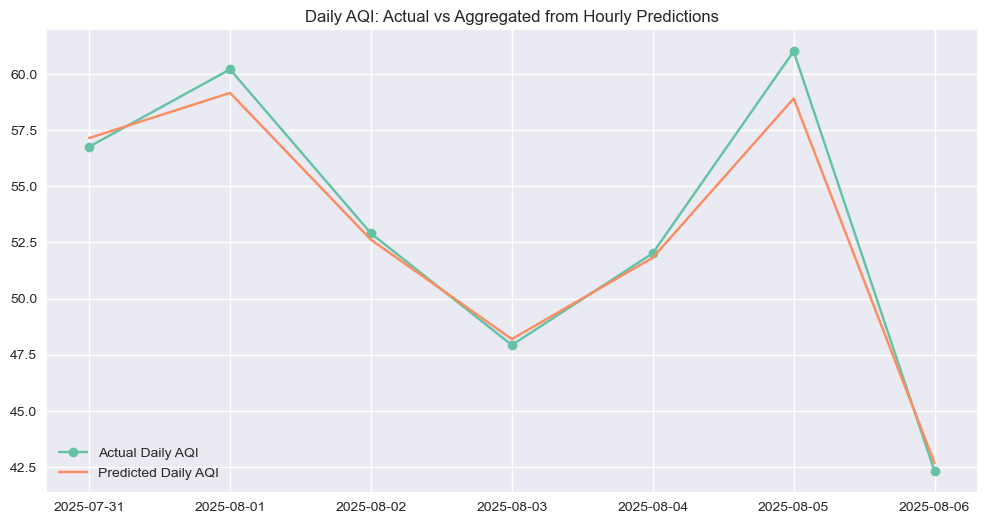

In [76]:
# Aggregate hourly pred, create daily averages from hourly predictions
daily_from_hourly = pd.DataFrame({
    'actual': y_test_h.resample('D').mean(),
    'predicted': pd.Series(test_pred_h, index=y_test_h.index).resample('D').mean()
})

#daily metrics
daily_rmse = np.sqrt(mean_squared_error(daily_from_hourly['actual'], daily_from_hourly['predicted']))
daily_mae = mean_absolute_error(daily_from_hourly['actual'], daily_from_hourly['predicted'])
daily_r2 = r2_score(daily_from_hourly['actual'], daily_from_hourly['predicted'])

print("Daily Aggregation of Hourly Predictions:")
print(f"RMSE: {daily_rmse:.2f}")
print(f"MAE: {daily_mae:.2f}")
print(f"R²: {daily_r2:.4f}")

#daily comparison
plt.figure(figsize=(12, 6))
plt.plot(daily_from_hourly.index, daily_from_hourly['actual'], label="Actual Daily AQI", marker='o')
plt.plot(daily_from_hourly.index, daily_from_hourly['predicted'], label="Predicted Daily AQI", marker='x')
plt.title("Daily AQI: Actual vs Aggregated from Hourly Predictions")
plt.legend()
plt.grid(True)
plt.show()

**Compare hourly and daily models**

Model Comparison:
          Model  Train RMSE  Validation RMSE  Test RMSE   Test R²
0   Daily Model    6.153360         1.875932   2.653763  0.817505
1  Hourly Model    0.494686         1.723128   4.795194  0.971723


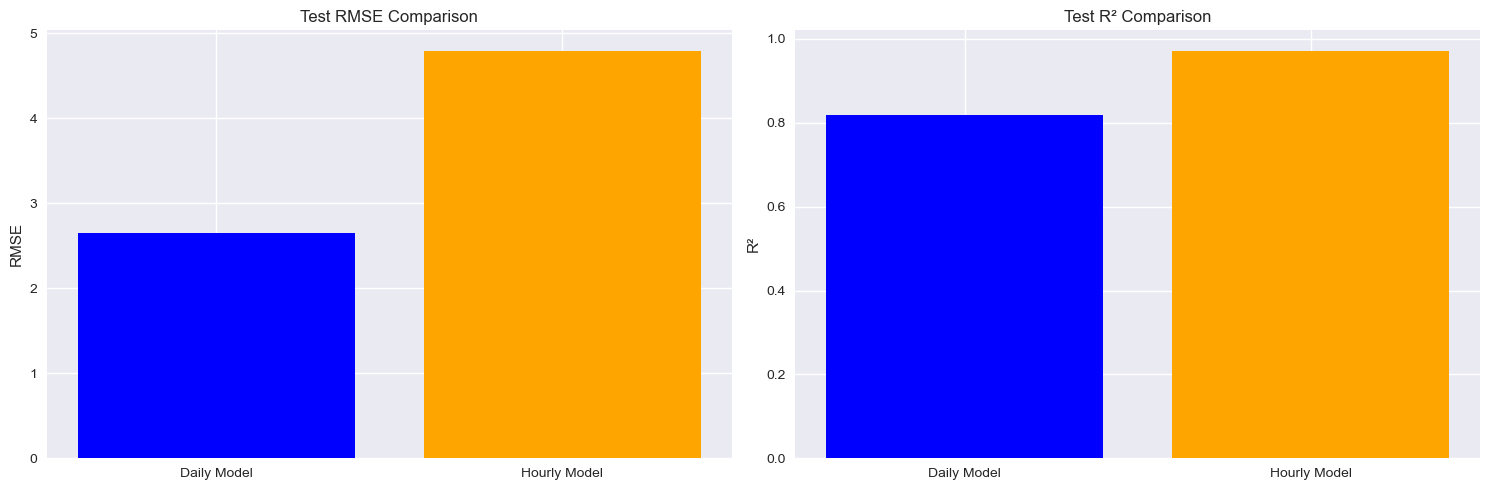

In [77]:
comparison_data = {
    'Model': ['Daily Model', 'Hourly Model'],
    'Train RMSE': [train_metrics[0], train_metrics_h[0]],
    'Validation RMSE': [val_metrics[0], val_metrics_h[0]],
    'Test RMSE': [test_metrics[0], test_metrics_h[0]],
    'Test R²': [test_metrics[2], test_metrics_h[2]]
}

comparison_df = pd.DataFrame(comparison_data)
print("Model Comparison:")
print(comparison_df)

#Plot
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

#RMSE
axes[0].bar(comparison_df['Model'], comparison_df['Test RMSE'], color=['blue', 'orange'])
axes[0].set_title('Test RMSE Comparison')
axes[0].set_ylabel('RMSE')

#R2 comparison
axes[1].bar(comparison_df['Model'], comparison_df['Test R²'], color=['blue', 'orange'])
axes[1].set_title('Test R² Comparison')
axes[1].set_ylabel('R²')

plt.tight_layout()
plt.show()

In [78]:
def categorize_aqi(aqi):
    if aqi <= 50:
        return "Good"
    elif aqi <= 100:
        return "Satisfactory"
    elif aqi <= 200:
        return "Moderate"
    elif aqi <= 300:
        return "Poor"
    elif aqi <= 400:
        return "Very Poor"
    else:
        return "Severe"

#Convert for daily model
y_test_categories = y_test.apply(categorize_aqi)
test_pred_categories = pd.Series(test_pred).apply(categorize_aqi)

#Convert for hourly model
y_test_h_categories = y_test_h.apply(categorize_aqi)
test_pred_h_categories = pd.Series(test_pred_h).apply(categorize_aqi)

In [80]:
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

print("DAILY MODEL CLASSIFICATION REPORT")
print("=" * 50)

#unique labels
daily_labels = sorted(list(set(y_test_categories) | set(test_pred_categories)))
print(classification_report(y_test_categories, test_pred_categories,
                           labels=daily_labels,
                           target_names=daily_labels))
print(f"Overall Accuracy: {accuracy_score(y_test_categories, test_pred_categories):.4f}")
print("\n")

print("HOURLY MODEL CLASSIFICATION REPORT")
print("=" * 50)

hourly_labels = sorted(list(set(y_test_h_categories) | set(test_pred_h_categories)))
print(classification_report(y_test_h_categories, test_pred_h_categories,
                           labels=hourly_labels,
                           target_names=hourly_labels))
print(f"Overall Accuracy: {accuracy_score(y_test_h_categories, test_pred_h_categories):.4f}")

DAILY MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       1.00      1.00      1.00         2
Satisfactory       1.00      1.00      1.00         5

    accuracy                           1.00         7
   macro avg       1.00      1.00      1.00         7
weighted avg       1.00      1.00      1.00         7

Overall Accuracy: 1.0000


HOURLY MODEL CLASSIFICATION REPORT
              precision    recall  f1-score   support

        Good       1.00      0.99      1.00       279
    Moderate       1.00      0.83      0.91         6
        Poor       1.00      1.00      1.00         2
Satisfactory       0.99      1.00      0.99       224
   Very Poor       1.00      1.00      1.00         2

    accuracy                           0.99       513
   macro avg       1.00      0.97      0.98       513
weighted avg       0.99      0.99      0.99       513

Overall Accuracy: 0.9942


In [108]:
import joblib

# Save only the model
joblib.dump(hourly_model, "hourly_model.pkl")

# Save the training feature columns (important for inference later!)
joblib.dump(X_train_h.columns.tolist(), "hourly_features.pkl")

print("✅ Model and feature list saved.")


✅ Model and feature list saved.


In [109]:
# Load model
hourly_model_loaded = joblib.load("hourly_model.pkl")

# Load feature order
hourly_features = joblib.load("hourly_features.pkl")

print("Loaded model:", type(hourly_model_loaded))
print("Loaded features:", hourly_features[:10])  # show first 10 features


Loaded model: <class 'sklearn.ensemble._gb.GradientBoostingRegressor'>
Loaded features: ['co', 'no', 'no2', 'o3', 'pm10', 'pm25', 'relativehumidity', 'so2', 'temperature', 'hour']


In [114]:
# Step 1: Create features on the test set
test_feats = create_hourly_features(test_hourly)

# Step 2: Align with training features
X_test = test_feats[hourly_features]
y_test = test_feats["aqi"]   # assuming 'aqi' is your target column

# Step 3: Make predictions
y_pred = hourly_model_loaded.predict(X_test)

# Step 4: Evaluate performance
from sklearn.metrics import mean_squared_error, r2_score
import numpy as np

mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("RMSE:", rmse)
print("R²:", r2)

# Step 5: (Optional) Save predictions
test_feats["predicted_aqi"] = y_pred
test_feats.to_csv("test_predictions.csv", index=False)


KeyError: 'aqi'

In [107]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer


numeric_features = ["day_of_month", "hour", "lag_1h", "lag_12h", "lag_24h"]
preprocessor = ColumnTransformer([
    ("scaler", StandardScaler(), numeric_features)
])

pipe = Pipeline([
    ("preprocessor", preprocessor),
    ("model", hourly_model)
])


df_new = test_hourly.copy()
df_new_feats = create_hourly_features(df_new)
X_new = df_new_feats[hourly_features]  
y_new_pred = pipeline.predict(X_new)

pipe.fit(X_train, y_train)
joblib.dump(pipe, "pipeline.pkl")


ValueError: A given column is not a column of the dataframe